<h3> SciPython/Practical_classes_7

<h1> Clustering. K-means

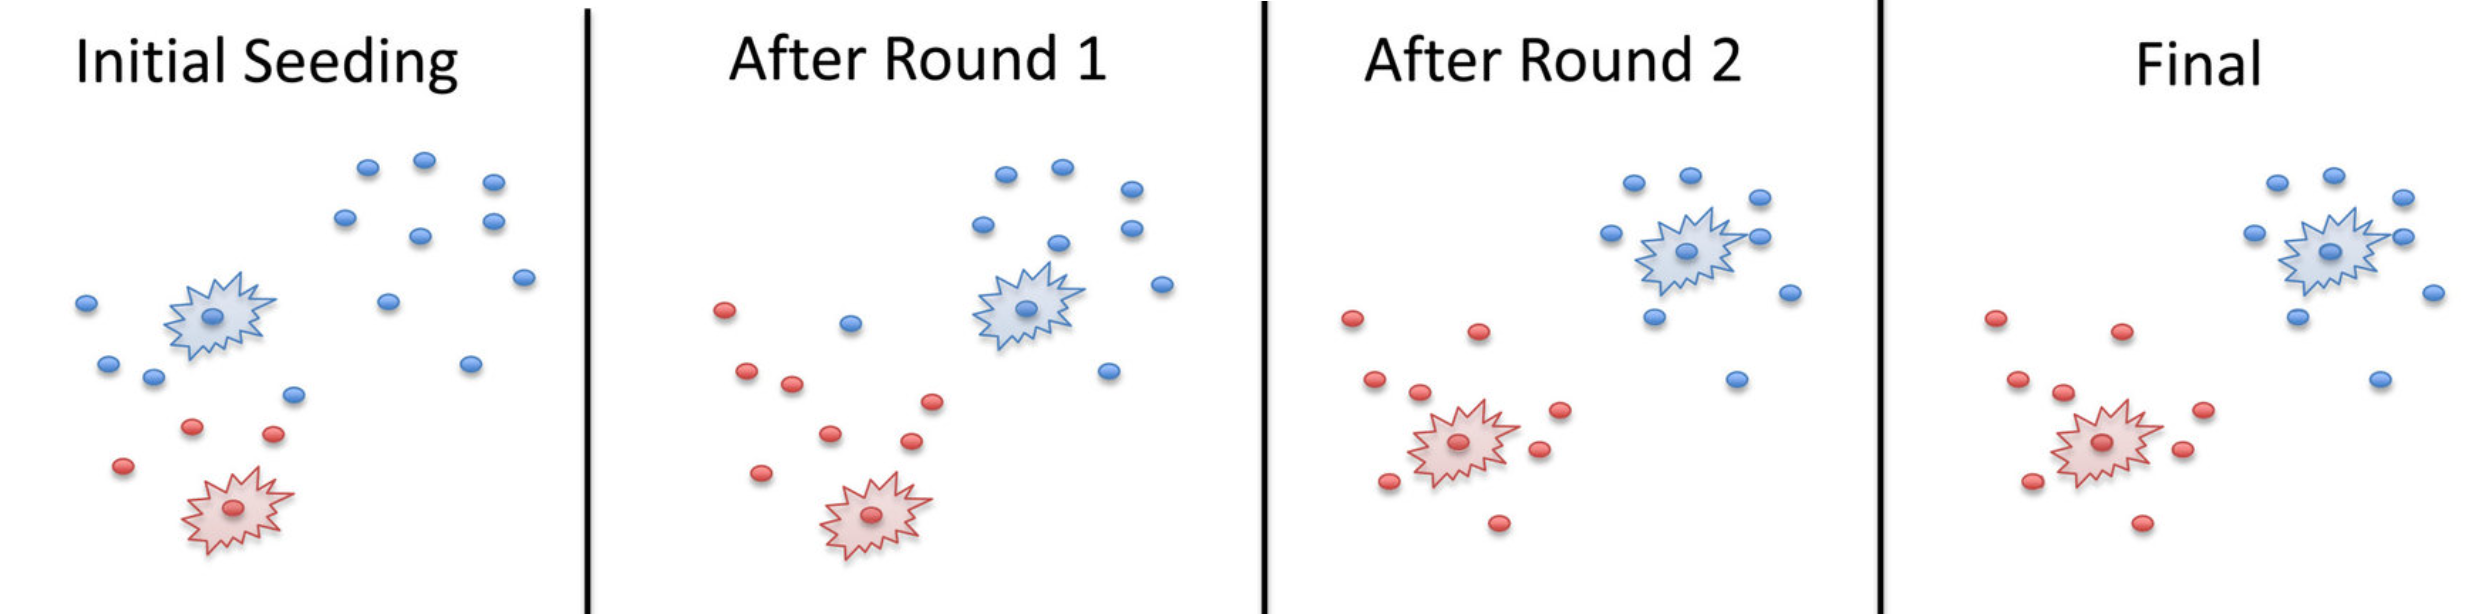

In [2]:
from IPython import display
display.Image("kmeans.png", width="1200", height="700")

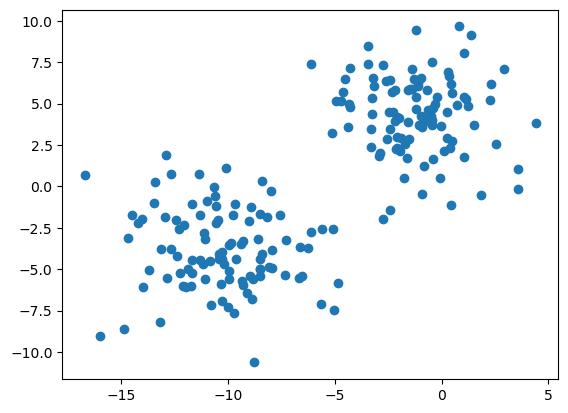

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=200, random_state=1, n_features=2, centers = 2, cluster_std = 2.4)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2) #specfify thenumber of cluster = 2
kmeans.fit(X);

In [4]:
print(kmeans.labels_[:10])

[1 1 1 0 1 1 0 1 0 1]


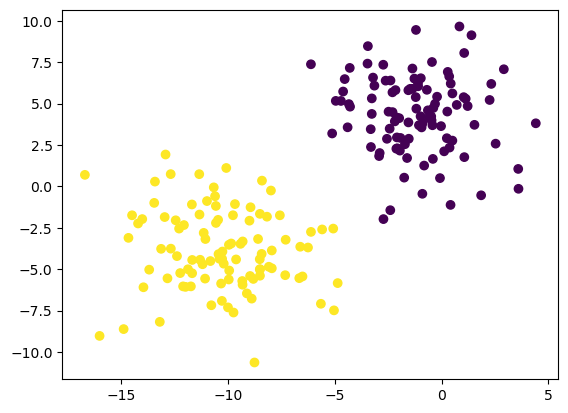

In [5]:
plt.scatter(X[:, 0], X[:, 1], c = kmeans.labels_)
plt.show()

In [6]:
kmeans.cluster_centers_ #where are centres localized?

array([[ -1.17963243,   4.34587916],
       [-10.27744713,  -3.83271163]])

In [8]:
import numpy as np
kmeans.predict(np.array([[-10,-5], [-10,0],[0,5]])) #which group? new observations

array([1, 1, 0], dtype=int32)

<h4> In practice, we don't know the number of clusters...

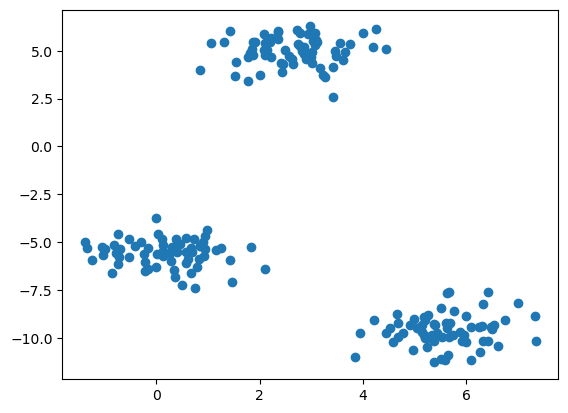

In [25]:
X, y = make_blobs(n_samples=200, random_state=10, n_features=2, centers = 3, cluster_std = 0.8)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

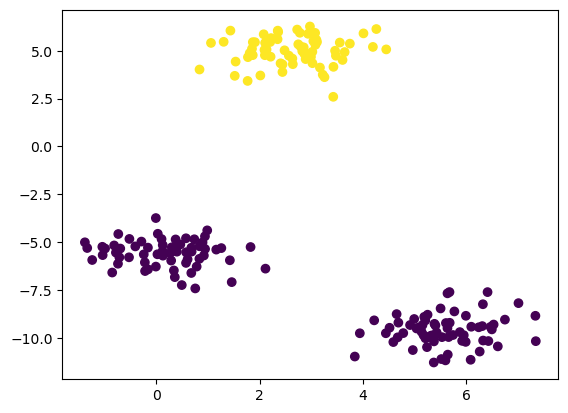

In [26]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X);
plt.scatter(X[:, 0], X[:, 1], c = kmeans.labels_)
plt.show()

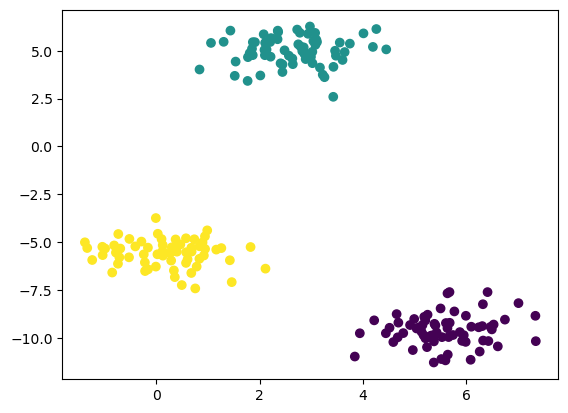

In [27]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X);
plt.scatter(X[:, 0], X[:, 1], c = kmeans.labels_)
plt.show()

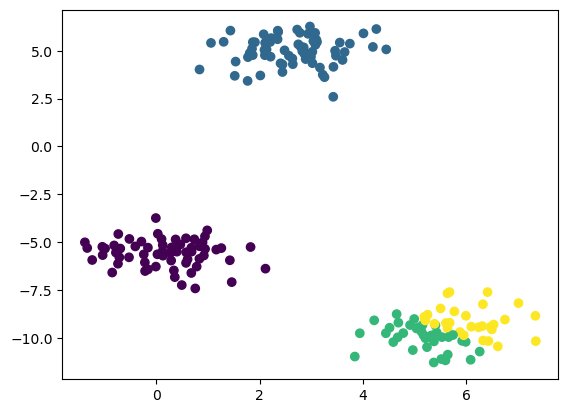

In [28]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(X);
plt.scatter(X[:, 0], X[:, 1], c = kmeans.labels_)
plt.show()

Silhouette Score and Davies–Bouldin Score are two common metrics used to evaluate the quality of clustering results, but they focus on slightly different aspects.

The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters. It looks at how close a point is to other points in the same cluster and how far it is from points in the nearest neighboring cluster (separation). The final score is an average over all points. Its values range from -1 to 1, where values close to 1 indicate well-separated and compact clusters. In practice, scores above about 0.5 are considered good, and above 0.7 very good.

The Davies–Bouldin Score evaluates clustering by comparing the average similarity between each cluster and its most similar one, taking into account both the spread within clusters and the distance between cluster centers. Unlike the Silhouette Score, lower values are better here. A score close to 0 indicates that clusters are compact and well separated, while higher values suggest that clusters are less distinct and more dispersed. There is no strict upper bound, but in general, the closer the score is to zero, the better the clustering quality.

In [29]:
from sklearn.metrics import silhouette_score 

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    print(i, silhouette_score(X, kmeans.fit_predict(X)))

2 0.7482786450557023
3 0.8257519013796625
4 0.6690555492051706
5 0.5065671672122748
6 0.49973652866985335
7 0.3131697465650335
8 0.33134308069420215
9 0.3234747151193358


In [30]:
from sklearn.metrics import davies_bouldin_score

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    print(i, davies_bouldin_score(X, kmeans.fit_predict(X)))

2 0.34865010770736826
3 0.24045823423472665
4 0.6900123349272187
5 0.9793335379213065
6 0.9195328207234715
7 1.108735933570432
8 1.004365090936195
9 0.9948614935293931


<h4> Example1: Digits clustering

In [32]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.data.shape #1797 images, 8x8 size

(1797, 64)

In [33]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

In [34]:
kmeans = KMeans(n_clusters = 10, random_state=3)
clusters = kmeans.fit_predict(digits.data)
print(kmeans.cluster_centers_.shape) #10 clusters 64D

(10, 64)


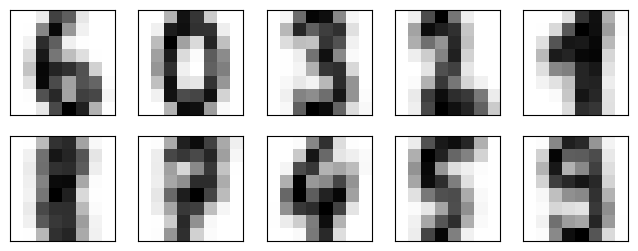

In [35]:
#how these centers looks like? Which digitis seems to be easy or difficult to classify?

fig, ax = plt.subplots(2, 5, figsize = (8,3))
centers = kmeans.cluster_centers_.reshape(10,8,8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks = [], yticks = [])
    axi.imshow(center, interpolation = "nearest", cmap = plt.cm.binary)

In [36]:
#k-means names the group arbitrary (for example 1 group may not correspond to "1 digit")
from collections import Counter

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = Counter(digits.target[mask]).most_common()[0][0] 

In [37]:
from sklearn.metrics import accuracy_score

accuracy_score(digits.target, labels)

0.7913188647746243

Text(50.722222222222214, 0.5, 'true label')

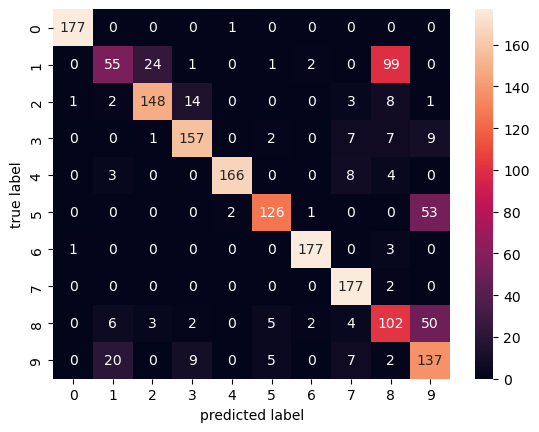

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat, annot=True, fmt="d",
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)

plt.xlabel("predicted label")
plt.ylabel("true label")  

<h4> Non-spherical shapes

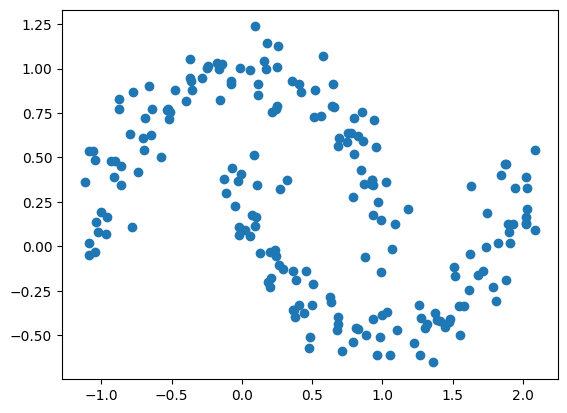

In [67]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=200, noise=.1, random_state=41)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

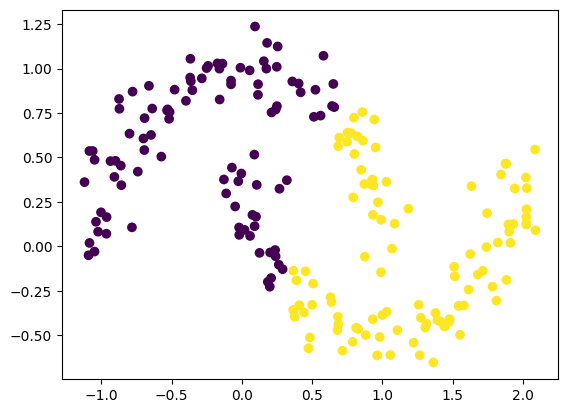

In [68]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X);
plt.scatter(X[:, 0], X[:, 1], c = kmeans.labels_)
plt.show() #not what we expect

<h4> DBSCAN

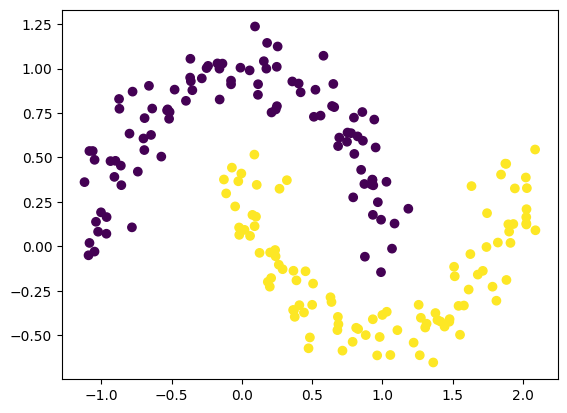

In [69]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.22, min_samples=1)
db.fit(X)

plt.scatter(X[:, 0], X[:, 1], c=db.labels_)
plt.show()

<h3> Hierarchical grouping

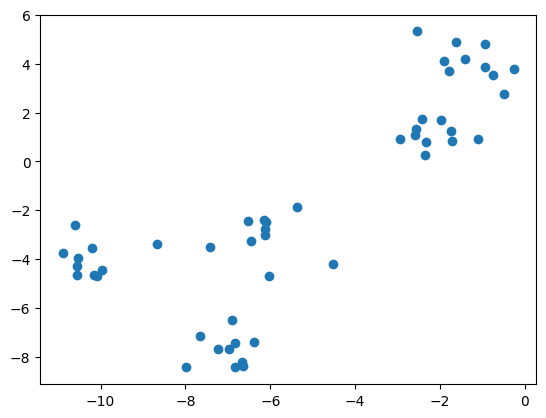

In [74]:
X, y = make_blobs(n_samples=50, random_state=1, n_features=2, centers = 5, cluster_std = 0.8)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

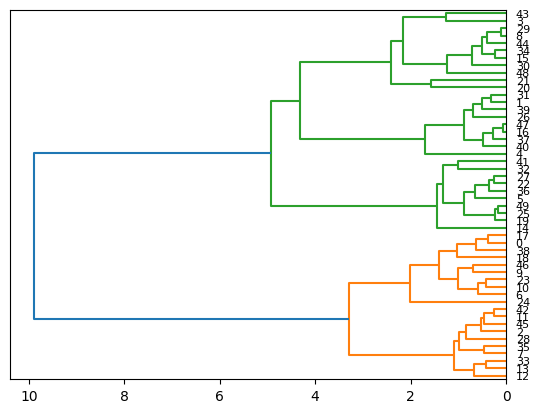

In [73]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_data = linkage(X, method='average', metric='euclidean')
dendrogram(linkage_data, orientation='left')
plt.show()

https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

<h4> Question: What are the other variants for method and metric? Save appropriate formulas, test, and compare them.

<h4> Exercise1:  Codon Frequency Clustering
    
- Consider the codon log frequencies in selected plants, viruses, and bacteria.

- Use the K-means algorithm with $k=3$ to divide the data into 3 clusters.

- Evaluate how well the predicted clusters correspond to the actual organism information.
   

In [136]:
import pandas as pd
import numpy as np

df = pd.read_csv("codon_usage.csv")
df = df[df['Kingdom'].isin(['pln', 'vrl','bct'])]
df['UGA;'] = df['UGA;'].str.replace(';', '')
y = df["Kingdom"]
X = df.drop(columns=["Kingdom","DNAtype", "SpeciesID", "Ncodons", "SpeciesName"]).apply(pd.to_numeric, errors='coerce').apply(lambda x: np.log(x + 0.001))

In [134]:
print(X)

           UUU       UUC       UUA       UUG       CUU       CUC       CUA  \
0    -4.043271 -4.340501 -6.502290 -5.401458 -4.340501 -3.408826 -6.214608   
1    -3.570563 -4.228791 -6.388961 -4.856199 -5.284414 -3.523704 -5.795898   
2    -3.875691 -3.780995 -4.228791 -4.108646 -4.730733 -4.413724 -4.484724   
3    -3.976562 -3.752885 -4.063427 -4.517159 -4.094145 -4.228105 -4.565949   
4    -3.534957 -4.219228 -4.747886 -3.275711 -4.213128 -5.039035 -5.162040   
...        ...       ...       ...       ...       ...       ...       ...   
8632 -3.988364 -3.793796 -4.807286 -3.367666 -3.758873 -3.906041 -4.713870   
8633 -2.749028 -3.878105 -3.162023 -3.704196 -3.312363 -5.310390 -3.978163   
8634 -3.337096 -3.761450 -4.248895 -3.903063 -3.587406 -3.972835 -4.513503   
8635 -4.528209 -3.579129 -3.700547 -6.907755 -4.011843 -5.719912 -6.907755   
9571 -4.258041 -4.095345 -4.628439 -4.303585 -4.766513 -5.114331 -4.695095   

           CUG       AUU       AUC  ...       CGG       AGA    

In [135]:
print(y)

0       vrl
1       vrl
2       vrl
3       vrl
4       vrl
       ... 
8632    pln
8633    pln
8634    pln
8635    pln
9571    bct
Name: Kingdom, Length: 8273, dtype: object


<h4> Exercise2: Consider the Breast Cancer dataset. Test different numbers of clusters to which the data can be partitioned using the K-means algorithm. What is the optimal value of k? Comment on the results

In [144]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign
X = df.drop("target", axis = 1)

<h4> Exercise3:  Influenza Virus Sequence Analysis

- Open the file "influenza viruses" containing nucleotide sequences of various influenza virus types.

- Represent each sequence as a vector of 4-mer frequencies, resulting in a matrix X.

- Compute the standard deviation for each 4-mer across virus groups. Select the two mers with the highest variation between groups and visualize the data, using colors to indicate virus types. Make a comment on it.

- Experiment with different numbers of top discriminative k-mers. Use these features to perform hierarchical clustering and attempt to group viruses of the same type together.